In [1]:
from langgraph.graph import StateGraph,END,add_messages
from typing import TypedDict,Annotated
from langgraph.types import Command,interrupt
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.tools import TavilySearchResults
from langchain_groq import ChatGroq
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage,HumanMessage


/Users/mohan/Desktop/codebasics/Langraph/venv/lib/python3.11/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
llm = ChatGroq(model="llama-3.1-8b-instant")

search_tool = TavilySearchResults(max_results=2)

avail_tools = [search_tool]

llm_with_tools = llm.bind_tools(tools=avail_tools)

memory = MemorySaver()

In [3]:
class graph_state(TypedDict):
    messages : Annotated[list,add_messages]

def chat_bot(state):
    response = llm_with_tools.invoke(state["messages"])
    return{
        "messages" : [response]
    }

def tools_decision(state):
    last_message = state["messages"][-1]
    if(hasattr(last_message,"tool_calls") and len(last_message.tool_calls)>0):
        return "tools"
    else:
        return END
    
tools = ToolNode(tools = avail_tools)

graph = StateGraph(graph_state)

graph.add_node("chat_bot",chat_bot)
graph.add_node("tools",tools)

graph.set_entry_point("chat_bot")
graph.add_conditional_edges("chat_bot",tools_decision)
graph.add_edge("tools","chat_bot")

app = graph.compile(checkpointer=memory,interrupt_before=["tools"])

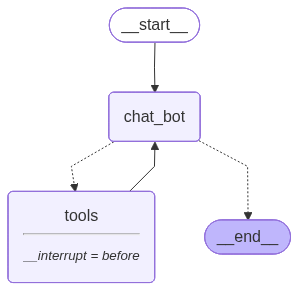

In [4]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
config = {
    "configurable":{
        "thread_id" : 1
    }
}

events = app.stream({
    "messages" : [HumanMessage(content="what is the capital of india")]
},
    config=config,
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is the capital of india
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (w8fvq3sm1)
 Call ID: w8fvq3sm1
  Args:
    query: capital of india


In [6]:
events = app.stream({
    "messages" : [HumanMessage(content="what is the weather in delhi")]
},
    config=config,
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is the weather in delhi
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (68fe0mxsg)
 Call ID: 68fe0mxsg
  Args:
    query: weather delhi


In [7]:
snapshot = app.get_state(config=config)
snapshot.next

('tools',)

In [8]:
events = app.stream(None,
    config=config,
    stream_mode="values"
)

for event in events:
    event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (68fe0mxsg)
 Call ID: 68fe0mxsg
  Args:
    query: weather delhi
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://mausam.imd.gov.in/newdelhi/mcdata/delhi_forecast.pdf", "content": "## 42-43°C during past 24 hours over Delhi .\n\n## • The minimum temperatures are above normal (1.6 °C to 3.0 °C) at isolated places and normal (-1.5 °C to \n\n## 1.5 °C) over remaining parts of Delhi .\n\n## • The maximum temperatur es were above normal ( 1.6 °C to 3.0 °C ) at many places and normal ( -1.5°C to \n\n## 1.5°C) over remaining parts of Delhi .\n\n## • West Southwesterly wind speed prevailed 15 -20 Kmph gusting to 33 Kmph during past 24 hours over \n\n## Delhi. Weather Observations over Safdarjung ending at 08 :30 Hrs. IST of today , 09 June 2026 \n\nMaximum Temperature \n\n(Previous day) \n\n